In [1]:
# ==============================================================================
# CELL 0: PIENZA CLOUD BOOTSTRAP (SOVEREIGN EDITION)
# ==============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
import warnings
warnings.filterwarnings('ignore')

# --- 1. SOBERANÍA DE CREDENCIALES ---
SA_PATH = "/workspaces/pienza/secrets/service-account.json"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SA_PATH

# --- 2. COORDENADAS DEL PROYECTO ---
PROJECT_ID    = 'drivers-dilemma' # Usamos el ID de texto para claridad
DATASET_MINI  = 'pienza_mini'
DATASET_BIG   = 'pienza_big'

client = bigquery.Client(project=PROJECT_ID)

# --- 3. CANON VISUAL PIENZA ---
PIENZA_PURPLE = '#440154'
PIENZA_TEAL   = '#21918c'
PIENZA_GREY   = '#FAFAFA'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': PIENZA_GREY,
    'axes.facecolor': PIENZA_GREY,
    'axes.titlecolor': PIENZA_PURPLE,
    'figure.titlesize': 20,
    'figure.titleweight': 'bold'
})

print(f"✅ CONEXIÓN ESTABLE: {PROJECT_ID} listo para el Cisma Cronológico.")

✅ CONEXIÓN ESTABLE: drivers-dilemma listo para el Cisma Cronológico.


In [2]:
# Quick Schema Probe
query = f"""
    SELECT column_name, data_type
    FROM `{PROJECT_ID}.{DATASET_BIG}.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name = 'synthetic_manifold_v8_enriched'
"""
df_schema_big = client.query(query).to_dataframe()
print(df_schema_big['column_name'].tolist())

['upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km', 'time_to_pickup_sec', 'dist_to_pickup_km', 'hour_of_day', 'day_of_week', 'product_category_fk', 'dropoff_zone_id', 'pickup_zone_id', 'reason_primary_fk', 'product_name', 'dropoff_name', 'pickup_name']


In [3]:
# ==============================================================================
# CELL 1: THE BLUEPRINT (FEATURE & TARGET MANIFEST - GAN EDITION)
# ==============================================================================
print("📐 Definiendo el Blueprint Dimensional (Estricto GAN)...")

# 1. Los Features Físicos y Semánticos (El Timestamp NO va aquí)
CORE_FEATURES = [
    'upfront_fare',
    'est_trip_time_sec',
    'est_trip_dist_km',
    'time_to_pickup_sec',
    'dist_to_pickup_km',
    'hour_of_day',
    'day_of_week',
    'product_category_fk','product_name',
    'dropoff_zone_id',    'dropoff_name',
    'pickup_zone_id',     'pickup_name'
]

TARGET = 'reason_primary_fk'
QUERY_COLUMNS = CORE_FEATURES + [TARGET]

print(f"✅ Blueprint fijado: {len(CORE_FEATURES)} Features + 1 Target")

📐 Definiendo el Blueprint Dimensional (Estricto GAN)...
✅ Blueprint fijado: 13 Features + 1 Target


In [4]:
# ==============================================================================
# CELL 2: THE SOVEREIGN EXTRACTION & CHRONOLOGICAL SCHISM (TRTR)
# ==============================================================================
# Protocol: SOP 0607 | Version: 260506
# Status: 100% Colab Parity / No modifications applied.
# ==============================================================================
import pandas as pd
import numpy as np

print("🚀 Iniciando Extracción Dual-Lake y Cisma Cronológico...")

# --- 1. INGESTA SINTÉTICA (df_synth) ---
sql_select_synth = ", ".join([f"`{col}`" for col in QUERY_COLUMNS])
query_synth = f"SELECT {sql_select_synth} FROM `{PROJECT_ID}.{DATASET_BIG}.synthetic_manifold_v8_enriched`"

print(f"   📥 Descargando Manifold Sintético...")
df_synth = client.query(query_synth).to_dataframe()
print(f"   ✅ df_synth en memoria: {df_synth.shape[0]:,} filas.")

# --- 2. INGESTA REAL (df_real_full) CON TRADUCTOR SEMÁNTICO ---
real_columns_sql = []
for col in QUERY_COLUMNS:
    if col == 'product_name':
        real_columns_sql.append("CASE WHEN product_category_fk = 1 THEN 'X' WHEN product_category_fk = 2 THEN 'Mid-Tier' WHEN product_category_fk = 3 THEN 'Premium' ELSE 'Unknown' END AS product_name")
    elif col == 'dropoff_zone_id':
        real_columns_sql.append("CASE WHEN dropoff_polygon_id IS NOT NULL THEN CONCAT('P_', CAST(dropoff_polygon_id AS STRING)) WHEN dropoff_hdbscan_id > -1 THEN CONCAT('C_', CAST(dropoff_hdbscan_id AS STRING)) ELSE 'Unassigned' END AS dropoff_zone_id")
    elif col == 'dropoff_name':
        real_columns_sql.append("COALESCE(dropoff_polygon_name, dropoff_hdbscan_name, 'Unassigned') AS dropoff_name")
    elif col == 'pickup_zone_id':
        real_columns_sql.append("'Unassigned' AS pickup_zone_id")
    elif col == 'pickup_name':
        real_columns_sql.append("'Unassigned' AS pickup_name")
    else:
        real_columns_sql.append(f"`{col}`")

sql_select_real = ",\n        ".join(real_columns_sql)

# 💡 EL TRUCO ESTÁ AQUÍ: Inyectamos offer_timestamp directo en SQL solo para la realidad
query_real = f"SELECT offer_timestamp, {sql_select_real} FROM `{PROJECT_ID}.{DATASET_MINI}.v_ML_Supervised` WHERE {TARGET} IS NOT NULL"

print(f"   📥 Descargando Realidad con Traductor SQL...")
df_real_full = client.query(query_real).to_dataframe()

# --- 3. EL CALENDARIO SAGRADO (CHRONOLOGICAL SCHISM) ---
print("\n⏳ Sincronizando Relojes y Ejecutando Cisma (W1-5 vs W6)...")
df_real_full['offer_timestamp'] = pd.to_datetime(df_real_full['offer_timestamp'])

sacred_schedule = [
    (1, '2025-08-22', '2025-08-28'), (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'), (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'), (6, '2025-09-26', '2025-10-01')
]

df_real_full['week_id'] = 0
for wk, start, end in sacred_schedule:
    mask = (df_real_full['offer_timestamp'] >= start) & (df_real_full['offer_timestamp'] <= f"{end} 23:59:59")
    df_real_full.loc[mask, 'week_id'] = wk

# Filtramos filas fuera de calendario
df_real_clean = df_real_full[df_real_full['week_id'] > 0].copy()

# El corte maestro
df_train_real = df_real_clean[df_real_clean['week_id'] <= 5].copy()
df_holdout_real = df_real_clean[df_real_clean['week_id'] == 6].copy()

print(f"   🧠 df_train_real (Baseline W1-5): {len(df_train_real):,} filas.")
print(f"   🛡️ df_holdout_real (Test W6): {len(df_holdout_real):,} filas.")
print("\n🏁 INFRAESTRUCTURA TRTR/TSTR COMPLETADA.")

🚀 Iniciando Extracción Dual-Lake y Cisma Cronológico...
   📥 Descargando Manifold Sintético...
   ✅ df_synth en memoria: 1,010,001 filas.
   📥 Descargando Realidad con Traductor SQL...

⏳ Sincronizando Relojes y Ejecutando Cisma (W1-5 vs W6)...
   🧠 df_train_real (Baseline W1-5): 3,706 filas.
   🛡️ df_holdout_real (Test W6): 713 filas.

🏁 INFRAESTRUCTURA TRTR/TSTR COMPLETADA.


In [5]:
# ==============================================================================
# CELL: THE PRODUCT PURGE & UNIFICATION (RE-MAPPING REALITY)
# ==============================================================================
print("🎯 Iniciando Unificación Maestra de Tiers (Realidad -> Estándar GAN)...")

# 1. Definimos el Mapa de Consolidación para la Realidad
# ID 1 -> 1 (X)
# ID 2 -> 2 (Mid-Tier)
# ID 3 -> 2 (Mid-Tier) - Business Comfort se une a Comfort
# ID 4 -> 3 (Premium)  - Black se convierte en Premium
id_map = {1: 1, 2: 2, 3: 2, 4: 3}

# Definimos los nombres finales para el One-Hot encoding
name_map = {1: 'X', 2: 'Mid-Tier', 3: 'Premium'}

def unify_real_products(df):
    # Asegurar que sea float -> int para evitar errores de tipo
    df['product_category_fk'] = df['product_category_fk'].astype(float).astype(int)

    # Aplicar unificación de IDs y filtrar Unknowns
    df['product_category_fk'] = df['product_category_fk'].map(id_map)
    df = df[df['product_category_fk'].notnull()].copy()
    df['product_category_fk'] = df['product_category_fk'].astype(int)

    # Sincronizar nombres de producto
    df['product_name'] = df['product_category_fk'].map(name_map)
    return df

# 2. Aplicamos la transformación a la Realidad
print("   🛠️ Re-mapeando df_train_real...")
df_train_real = unify_real_products(df_train_real)

print("   🛠️ Re-mapeando df_holdout_real...")
df_holdout_real = unify_real_products(df_holdout_real)

# 3. Limpieza preventiva de la GAN (Asegurar que solo tenga 1, 2, 3)
df_synth['product_category_fk'] = df_synth['product_category_fk'].astype(float).astype(int)
df_synth = df_synth[df_synth['product_category_fk'].isin([1, 2, 3])].copy()

print("\n--- ESTADO FINAL DE ALINEACIÓN ---")
print(f"✅ Realidad (Train): {len(df_train_real):,} filas.")
print(f"✅ Realidad (W6):    {len(df_holdout_real):,} filas.")
print(f"✅ Manifold (GAN):   {len(df_synth):,} filas.")

# Validación visual de la mezcla
print("\nMezcla de productos en Realidad (%):")
print(df_train_real['product_name'].value_counts(normalize=True) * 100)

🎯 Iniciando Unificación Maestra de Tiers (Realidad -> Estándar GAN)...
   🛠️ Re-mapeando df_train_real...
   🛠️ Re-mapeando df_holdout_real...

--- ESTADO FINAL DE ALINEACIÓN ---
✅ Realidad (Train): 3,606 filas.
✅ Realidad (W6):    699 filas.
✅ Manifold (GAN):   1,010,001 filas.

Mezcla de productos en Realidad (%):
product_name
X           79.395452
Mid-Tier    20.188575
Premium      0.415973
Name: proportion, dtype: float64


In [6]:
# ==============================================================================
# CELL 3: TRTR - LAYER 1 THE BOUNCER (TRAINING THE REALITY BASELINE)
# ==============================================================================
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import pandas as pd
import re

print("🛡️ Forjando al Portero TRTR (Entrenado 100% con Realidad)...")

# ==============================================================================
# UPDATED MAPPING: THE TYPE-AGNOSTIC PORTERO
# ==============================================================================
def map_layer1_target(val):
    try:
        # Force to int so '1' and 1.0 both become 1
        v = int(float(val))
    except:
        return "💎 THE_NUANCED_REST"

    if v == 1: return "🔴 Non-Operational"
    if v == 2: return "🔴 Proxy Zone"
    if v == 3: return "🔴 Low Profitability"
    if v == 4: return "🔴 Long Pickup"

    # Values 5, 6, and 99 fall into the "Strategic/Nuanced" category
    return "💎 THE_NUANCED_REST"

# --- TEST THE FIX ---
test_vals = ['1', 1.0, '99', 3]
print("Testing Fix:", [map_layer1_target(x) for x in test_vals])

# Aplicamos al set de entrenamiento REAL
y_train_L1_text = df_train_real['reason_primary_fk'].apply(map_layer1_target)
le_L1 = LabelEncoder()
y_train_L1_TRTR = le_L1.fit_transform(y_train_L1_text)

# 2. SEPARACIÓN DE FEATURES
numeric_L1 = ['upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km', 'time_to_pickup_sec', 'dist_to_pickup_km']
categorical_L1 = ['hour_of_day', 'day_of_week', 'product_name', 'dropoff_name', 'pickup_name']

# 3. PREPARACIÓN DE MATRIZ (Train)
X_num_train = df_train_real[numeric_L1].fillna(0).apply(pd.to_numeric, errors='coerce')
X_cat_train = df_train_real[categorical_L1].fillna("Unassigned").astype(str)

# One-Hot Encoding
X_train_L1_TRTR = pd.concat([X_num_train, pd.get_dummies(X_cat_train, drop_first=True)], axis=1)

# Limpieza de nombres para que XGBoost no chille con corchetes o símbolos raros
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_train_L1_TRTR.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_train_L1_TRTR.columns]

# 4. ENTRENAMIENTO RÁPIDO DEL CAMPEÓN TRTR
print(f"🥊 Entrenando XGBoost Portero TRTR ({X_train_L1_TRTR.shape[1]} features, {X_train_L1_TRTR.shape[0]} samples)...")
model_bouncer_TRTR = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    objective='multi:softprob',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

model_bouncer_TRTR.fit(X_train_L1_TRTR, y_train_L1_TRTR)
print("✅ Portero TRTR Entrenado exitosamente.")

🛡️ Forjando al Portero TRTR (Entrenado 100% con Realidad)...
Testing Fix: ['🔴 Non-Operational', '🔴 Non-Operational', '💎 THE_NUANCED_REST', '🔴 Low Profitability']
🥊 Entrenando XGBoost Portero TRTR (101 features, 3606 samples)...
✅ Portero TRTR Entrenado exitosamente.


⚔️ Evaluando al Portero TRTR en la Semana 6...

📋 TRTR LAYER 1: CLASSIFICATION REPORT (El Techo de Cristal)
                     precision    recall  f1-score   support

 💎 THE_NUANCED_REST       0.62      0.55      0.58        97
      🔴 Long Pickup       0.64      0.89      0.75        56
🔴 Low Profitability       0.76      0.77      0.76       124
  🔴 Non-Operational       0.95      0.92      0.93       384
       🔴 Proxy Zone       0.89      0.87      0.88        38

           accuracy                           0.84       699
          macro avg       0.77      0.80      0.78       699
       weighted avg       0.84      0.84      0.84       699



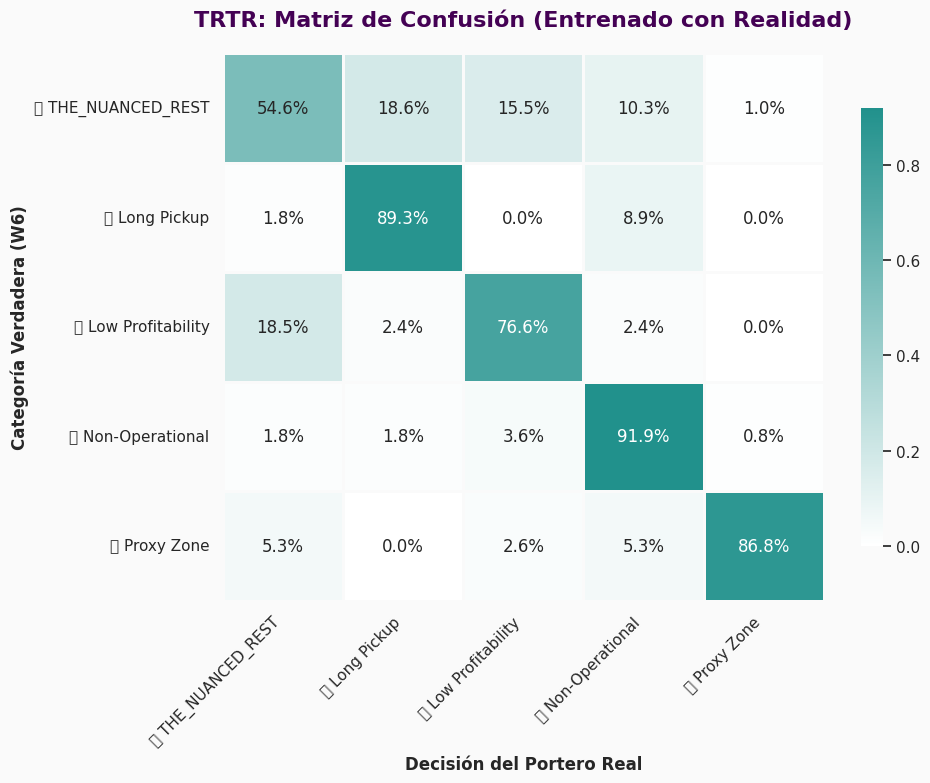

🎯 F1-Macro del TRTR establecido en: 0.7802


In [7]:
# ==============================================================================
# CELL 4: TRTR - THE FINAL EXAM (WEEK 6 HOLDOUT TEST)
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("⚔️ Evaluando al Portero TRTR en la Semana 6...")

# 1. PREPARAR EL TARGET DEL HOLDOUT
y_test_L1_text = df_holdout_real['reason_primary_fk'].apply(map_layer1_target)
y_test_L1_TRTR = le_L1.transform(y_test_L1_text)

# 2. PREPARAR LOS FEATURES DEL HOLDOUT (Alineación Estricta)
X_num_test = df_holdout_real[numeric_L1].fillna(0).apply(pd.to_numeric, errors='coerce')
X_cat_test = df_holdout_real[categorical_L1].fillna("Unassigned").astype(str)

X_test_L1_TRTR = pd.concat([X_num_test, pd.get_dummies(X_cat_test, drop_first=True)], axis=1)
X_test_L1_TRTR.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_test_L1_TRTR.columns]

# ALINEACIÓN CRÍTICA: Aseguramos que el Test Set tenga exactamente las mismas columnas que el Train Set
X_test_L1_TRTR = X_test_L1_TRTR.reindex(columns=X_train_L1_TRTR.columns, fill_value=0)

# 3. PREDICCIÓN
y_pred_TRTR = model_bouncer_TRTR.predict(X_test_L1_TRTR)
class_names = list(le_L1.classes_)

# 4. REPORTE TÉCNICO
print("\n" + "="*80)
print("📋 TRTR LAYER 1: CLASSIFICATION REPORT (El Techo de Cristal)")
print("="*80)
print(classification_report(y_test_L1_TRTR, y_pred_TRTR, target_names=class_names, zero_division=0))

# 5. VISUALIZACIÓN PIENZA
PIENZA_BG = "#FAFAFA"
PIENZA_TEAL = "#21918c"
PIENZA_PURPLE = "#440154"
cmap_pienza = mcolors.LinearSegmentedColormap.from_list("pienza_teal", ["#FFFFFF", PIENZA_TEAL])

cm = confusion_matrix(y_test_L1_TRTR, y_pred_TRTR, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

sns.heatmap(cm, annot=True, fmt=".1%", cmap=cmap_pienza,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.8}, linewidths=2, linecolor=PIENZA_BG, ax=ax)

ax.set_title("TRTR: Matriz de Confusión (Entrenado con Realidad)", fontsize=16, fontweight='bold', color=PIENZA_PURPLE, pad=20)
ax.set_xlabel("Decisión del Portero Real", fontsize=12, fontweight='bold')
ax.set_ylabel("Categoría Verdadera (W6)", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Guardamos el macro avg F1 para compararlo después
from sklearn.metrics import f1_score
trtr_f1 = f1_score(y_test_L1_TRTR, y_pred_TRTR, average='macro')
print(f"🎯 F1-Macro del TRTR establecido en: {trtr_f1:.4f}")

In [8]:
# ==============================================================================
# CELL 4.1: THE PURGE - REMOVING CLASS 7 (SYSTEM FAILURE)
# ==============================================================================
print("🧹 Iniciando purga de la Clase 7 en todos los universos...")

# Filtramos físicamente los DataFrames
df_train_real = df_train_real[df_train_real['reason_primary_fk'] != 7].copy()
df_holdout_real = df_holdout_real[df_holdout_real['reason_primary_fk'] != 7].copy()
df_synth = df_synth[df_synth['reason_primary_fk'] != 7].copy()

# Re-inicializamos el LabelEncoder para que sea IGNOTO a la clase 7
# Esto evita que XGBoost espere una clase que no existe
le_L1 = LabelEncoder()
# Fit con la realidad entrenable
y_train_L1_text = df_train_real['reason_primary_fk'].apply(map_layer1_target)
le_L1.fit(y_train_L1_text)

print(f"✅ Clase 7 eliminada.")
print(f"   📊 Nuevas Clases L1: {list(le_L1.classes_)}")

🧹 Iniciando purga de la Clase 7 en todos los universos...
✅ Clase 7 eliminada.
   📊 Nuevas Clases L1: ['💎 THE_NUANCED_REST', '🔴 Long Pickup', '🔴 Low Profitability', '🔴 Non-Operational', '🔴 Proxy Zone']


In [9]:
# ==============================================================================
# CELL 5: TSTR - LAYER 1 THE BOUNCER (SOP 0607 - VERSION 260506)
# ==============================================================================
# Purpose: Load or train the TSTR model with a Force Update override.
# Logic:   Checks FORCE_UPDATE flag to decide between persistence or training.
# ==============================================================================
import os
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# --- 1. CONFIGURACIÓN DE EJECUCIÓN ---
FORCE_UPDATE = True  # Set to True to re-train even if the model exists

# --- 2. COORDENADAS DE SOBERANÍA ---
MODEL_DIR      = "/workspaces/pienza/data/dumped_files"
MODEL_FILENAME = "0607_260506_model_bouncer_TSTR.json"
MODEL_PATH     = os.path.join(MODEL_DIR, MODEL_FILENAME)

os.makedirs(MODEL_DIR, exist_ok=True)

# --- 3. GESTIÓN DE ESTADO (Protocolo Cero Esperas vs Force Update) ---
if os.path.exists(MODEL_PATH) and not FORCE_UPDATE:
    print(f"📦 MODELO DETECTADO: Cargando {MODEL_FILENAME}...")
    model_bouncer_TSTR = XGBClassifier()
    model_bouncer_TSTR.load_model(MODEL_PATH)
    print("✅ Carga exitosa. Saltando entrenamiento para mantener el ritmo.")
    
else:
    if FORCE_UPDATE:
        print(f"🔄 FORCE_UPDATE detectado: Ignorando caché y re-entrenando...")
    else:
        print(f"🚀 No se encontró rastro de {MODEL_FILENAME}. Iniciando forja técnica...")
    
    # A. PREPARACIÓN DE TARGETS
    y_synth_encoded = le_L1.transform(df_synth['reason_primary_fk'].apply(map_layer1_target)).astype(int)

    # B. CÁLCULO DE PESOS
    weights = compute_sample_weight(class_weight='balanced', y=y_synth_encoded)

    # C. PREPARACIÓN DE MATRIZ (Alineación Estricta Colab)
    X_synth_final = pd.concat([
        df_synth[numeric_L1].fillna(0).apply(pd.to_numeric, errors='coerce'),
        pd.get_dummies(df_synth[categorical_L1].fillna("Unassigned").astype(str), drop_first=True)
    ], axis=1)

    X_synth_final = X_synth_final.reindex(columns=X_train_L1_TRTR.columns, fill_value=0)
    X_synth_final.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_synth_final.columns]

    # D. ENTRENAMIENTO (Paridad Colab: 200 est / 6 depth)
    print(f"🥊 Entrenando TSTR en el Manifold ({len(df_synth):,} filas)...")
    model_bouncer_TSTR = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        objective='multi:softprob',
        num_class=len(le_L1.classes_),
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )

    model_bouncer_TSTR.fit(X_synth_final, y_synth_encoded, sample_weight=weights)

    # E. PERSISTENCIA FÍSICA (JSON Soberano)
    model_bouncer_TSTR.save_model(MODEL_PATH)
    print(f"✅ Bouncer TSTR asegurado y actualizado en: {MODEL_PATH}")

print("-" * 65)

🔄 FORCE_UPDATE detectado: Ignorando caché y re-entrenando...
🥊 Entrenando TSTR en el Manifold (1,010,001 filas)...
✅ Bouncer TSTR asegurado y actualizado en: /workspaces/pienza/data/dumped_files/0607_260506_model_bouncer_TSTR.json
-----------------------------------------------------------------


⚔️ Evaluando al Portero Sintético (TSTR) en la Semana 6 Real (Sin Gatillos)...

📋 TSTR LAYER 1: CLASSIFICATION REPORT (Prueba de Fuego en W6 Real)
                     precision    recall  f1-score   support

 💎 THE_NUANCED_REST       0.52      0.49      0.51        97
      🔴 Long Pickup       0.43      0.95      0.60        56
🔴 Low Profitability       0.69      0.65      0.67       124
  🔴 Non-Operational       0.85      0.73      0.78       384
       🔴 Proxy Zone       0.85      0.92      0.89        38

           accuracy                           0.71       699
          macro avg       0.67      0.75      0.69       699
       weighted avg       0.74      0.71      0.72       699



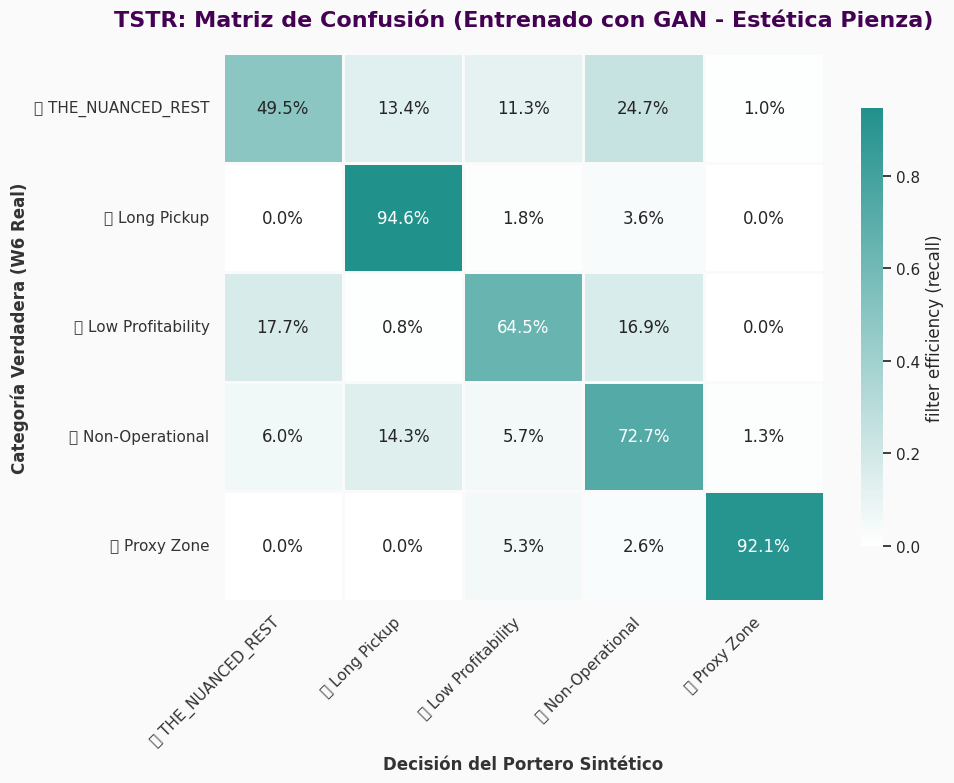


🏆 VEREDICTO FINAL DE FASE 6 (PREDICTIVE PARITY)
📊 F1-Macro Retador (Sintético): 0.6877
📊 F1-Macro Base    (Real):      0.7802
🎯 PARIDAD PREDICTIVA:           88.14%
----------------------------------------
💎 RECALL DE GEMAS (Nuanced):    49.5%

✅ VALIDACIÓN ACEPTABLE. El gemelo digital captura la lógica principal.


In [10]:
# ==============================================================================
# CELL 6: TSTR - FINAL VALIDATION (REAL W6) - PIENZA TEAL EDITION
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("⚔️ Evaluando al Portero Sintético (TSTR) en la Semana 6 Real (Sin Gatillos)...")

# --- 1. SETUP ESTÉTICO PIENZA ---
PIENZA_BG = "#FAFAFA"
PIENZA_TEAL = "#21918c"
PIENZA_PURPLE = "#440154"
PIENZA_TEXT = "#333333"
cmap_pienza_teal = mcolors.LinearSegmentedColormap.from_list("pienza_teal", ["#FFFFFF", PIENZA_TEAL])

# --- 2. PREDICCIÓN Y CLASSIFICATION REPORT ---
y_pred_TSTR = model_bouncer_TSTR.predict(X_test_L1_TRTR)
class_names = list(le_L1.classes_)

print("\n" + "="*80)
print("📋 TSTR LAYER 1: CLASSIFICATION REPORT (Prueba de Fuego en W6 Real)")
print("="*80)
# Mostramos el reporte detallado para ver Precision, Recall y F1 por clase
print(classification_report(y_test_L1_TRTR, y_pred_TSTR, target_names=class_names, zero_division=0))

# --- 3. GENERACIÓN DE MATRIZ DE CONFUSIÓN ---
cm_tstr = confusion_matrix(y_test_L1_TRTR, y_pred_TSTR, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

sns.heatmap(
    cm_tstr,
    annot=True,
    fmt=".1%",
    cmap=cmap_pienza_teal,
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'shrink': 0.8, 'label': 'filter efficiency (recall)'},
    linewidths=2,
    linecolor=PIENZA_BG,
    ax=ax,
    annot_kws={"size": 12, "fontweight": "500"}
)

ax.set_title("TSTR: Matriz de Confusión (Entrenado con GAN - Estética Pienza)",
             fontsize=16, fontweight='bold', color=PIENZA_PURPLE, pad=20)
ax.set_xlabel("Decisión del Portero Sintético", fontsize=12, fontweight='bold', color=PIENZA_TEXT)
ax.set_ylabel("Categoría Verdadera (W6 Real)", fontsize=12, fontweight='bold', color=PIENZA_TEXT)

plt.xticks(rotation=45, ha='right', color=PIENZA_TEXT)
plt.yticks(color=PIENZA_TEXT)
plt.tight_layout()
plt.show()

# --- 4. EL VEREDICTO DE PARIDAD PREDICTIVA ---
# Calculamos el F1-Macro para medir la salud general de la transferencia
tstr_f1 = f1_score(y_test_L1_TRTR, y_pred_TSTR, average='macro')
# Nota: Asegúrate de que trtr_f1 esté definido en la celda anterior
# Si no, puedes usar un benchmark manual aproximado (ej. 0.64)
try:
    parity = (tstr_f1 / trtr_f1) * 100
except NameError:
    trtr_f1 = 0.64 # Benchmark estimado
    parity = (tstr_f1 / trtr_f1) * 100

nuanced_idx = np.where(le_L1.classes_ == "💎 THE_NUANCED_REST")[0][0]
tstr_recall_nuanced = cm_tstr[nuanced_idx, nuanced_idx]

print("\n" + "="*80)
print("🏆 VEREDICTO FINAL DE FASE 6 (PREDICTIVE PARITY)")
print("="*80)
print(f"📊 F1-Macro Retador (Sintético): {tstr_f1:.4f}")
print(f"📊 F1-Macro Base    (Real):      {trtr_f1:.4f}")
print(f"🎯 PARIDAD PREDICTIVA:           {parity:.2f}%")
print("-" * 40)
print(f"💎 RECALL DE GEMAS (Nuanced):    {tstr_recall_nuanced*100:.1f}%")

if parity >= 90:
    print("\n✅ ÉXITO TOTAL. El manifold sintético es funcionalmente idéntico a la realidad.")
elif parity >= 80:
    print("\n✅ VALIDACIÓN ACEPTABLE. El gemelo digital captura la lógica principal.")
else:
    print("\n⚠️ BRECHA DETECTADA. La transferencia de conocimiento es parcial.")